In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon
import warnings
from monsoonbench.spatial.regions import get_india_outline
warnings.filterwarnings('ignore')
from plot_config import params, contourLevels, colormap, savefig_format, SMALL_SIZE, MEDIUM_SIZE, LARGE_SIZE

# Apply plot settings
plt.rcParams.update(params)
# Load the data
# data_path = '../fig_data/monsoon_cell_scores_2004_2021_ALL_CELLS.csv'
data_path = "outputs/fig6_data_recreation.csv"
df = pd.read_csv(data_path)
df = df.rename({
    "BSS": "fair_brier_skill",
    "RPS": "fair_rps_skill",
    "model": "dataset"
}, axis=1)

# Display data structure
print("Data shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nUnique horizons:")
print(df['horizon'].unique() if 'horizon' in df.columns else "No 'horizon' column found")

🎨 Scientific plotting configuration loaded
   Default save format: png
   Contour levels: 100
   Colormap: bwr
Data shape: (216, 7)

Column names:
['Unnamed: 0', 'fair_brier_skill', 'fair_rps_skill', 'lat', 'lon', 'horizon', 'dataset']

First few rows:
   Unnamed: 0  fair_brier_skill  fair_rps_skill   lat   lon  horizon   dataset
0           0         -0.542122        0.108574   8.0  76.0       15  FuXi-S2S
1           1         -0.253590       -0.158389   8.0  80.0       15  FuXi-S2S
2           2         -0.341767        0.311751  12.0  76.0       15  FuXi-S2S
3           3         -0.350027        0.090282  12.0  80.0       15  FuXi-S2S
4           4          0.117780        0.588308  16.0  76.0       15  FuXi-S2S

Unique horizons:
[15 30]


In [2]:
# def get_india_outline():
#     """
#     Get India outline coordinates. First try to load from shapefile, 
#     then fall back to simplified coordinates.
#     """
#     try:
#         # Try to load India shapefile - use the specified path first
#         shapefile_paths = [
#             '../fig_data/ind_map_shpfile/india_shapefile.shp',
#             'india_shapefile.shp'
#         ]
        
#         for path in shapefile_paths:
#             try:
#                 import geopandas as gpd
#                 india_gdf = gpd.read_file(path)
#                 # Extract boundary coordinates
#                 boundaries = []
#                 for geom in india_gdf.geometry:
#                     if hasattr(geom, 'exterior'):
#                         coords = list(geom.exterior.coords)
#                         lon_coords = [coord[0] for coord in coords]
#                         lat_coords = [coord[1] for coord in coords]
#                         boundaries.append((lon_coords, lat_coords))
#                     elif hasattr(geom, 'geoms'):
#                         for sub_geom in geom.geoms:
#                             if hasattr(sub_geom, 'exterior'):
#                                 coords = list(sub_geom.exterior.coords)
#                                 lon_coords = [coord[0] for coord in coords]
#                                 lat_coords = [coord[1] for coord in coords]
#                                 boundaries.append((lon_coords, lat_coords))
#                 return boundaries
#             except:
#                 continue
#     except:
#         pass
    
#     return [(india_lon, india_lat)]

# print("India outline function defined")

In [3]:
import xarray as xr

# Define the standard grid
lat_grid = np.arange(8, 37, 4)  # 8:4:36
lon_grid = np.arange(68, 101, 4)  # 68:4:100

def create_gridded_data(df, metric, model, horizon):
    """
    Convert CSV data to gridded xarray DataArray with standard lat-lon grid
    """
    # Filter data for specific model and horizon
    subset = df[(df['dataset'] == model) & (df['horizon'] == horizon)]
    
    if subset.empty:
        # Return empty grid with NaNs if no data
        data_grid = np.full((len(lat_grid), len(lon_grid)), np.nan)
        return xr.DataArray(
            data_grid, 
            coords={'lat': lat_grid, 'lon': lon_grid},
            dims=['lat', 'lon']
        )
    
    # Initialize grid with NaNs
    data_grid = np.full((len(lat_grid), len(lon_grid)), np.nan)
    
    # Fill grid with available data
    for _, row in subset.iterrows():
        lat_val = row['lat']
        lon_val = row['lon']
        
        # Find nearest grid point
        lat_idx = np.argmin(np.abs(lat_grid - lat_val))
        lon_idx = np.argmin(np.abs(lon_grid - lon_val))
        
        # Only assign if the point is close enough (within 0.1 degrees)
        if (np.abs(lat_grid[lat_idx] - lat_val) < 0.1 and 
            np.abs(lon_grid[lon_idx] - lon_val) < 0.1):
            # Multiply by 100 to convert to percentage
            data_grid[lat_idx, lon_idx] = row[metric] * 100
    
    # Create xarray DataArray
    da = xr.DataArray(
        data_grid, 
        coords={'lat': lat_grid, 'lon': lon_grid},
        dims=['lat', 'lon'],
        attrs={'units': 'skill_score_percent', 'model': model, 'horizon': horizon, 'metric': metric}
    )
    
    return da

In [4]:
# Define the models and metrics to plot
models = ['IFS', 'FuXi-S2S', 'NGCM']
metrics = ['fair_brier_skill', 'fair_rps_skill']
horizons = [15, 30]  # 15-day and 30-day horizons

# Model label mapping
model_labels = {
    'IFS': 'IFS',
    'FuXi-S2S': 'FuXi-S2S$^{\dagger}$',
    'NGCM': 'NGCM$^{\dagger}$'
}

# Plot configuration
SMALL_SIZE = 6
MEDIUM_SIZE = 7
LARGE_SIZE = 8

# Define Core Monsoon Zone polygon (same as reference)
polygon1_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
polygon1_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])

panel_linewidth = 0.5
map_lw = 0.5
polygon_lw = 1
tick_length = 2
tick_width = 0.5

In [5]:
def create_skill_map_panel_xr(ax, data_array, model, 
                             vmin=-100, vmax=100, show_ylabel=True, title=None):
    """
    Create a skill map panel using xarray DataArray with India boundaries
    """
    
    if data_array.isnull().all():
        ax.text(0.5, 0.5, f'No data for {model}', 
                transform=ax.transAxes, ha='center', va='center')
        return None
    
    # Get coordinates
    lats = data_array.lat.values
    lons = data_array.lon.values
    
    # Create edges for pcolormesh
    lat_edges = np.concatenate([lats - 2, [lats[-1] + 2]])
    lon_edges = np.concatenate([lons - 2, [lons[-1] + 2]])
    
    # Create pcolormesh plot
    im = ax.pcolormesh(lon_edges, lat_edges, data_array.values,
                      transform=ccrs.PlateCarree(),
                      cmap='RdBu', vmin=vmin, vmax=vmax, shading='flat')
    
    # Add India boundaries using the get_india_outline function
    try:
        india_boundaries = get_india_outline()
        for boundary in india_boundaries:
            india_lon, india_lat = boundary
            ax.plot(india_lon, india_lat, color='black', linewidth=map_lw, 
                   transform=ccrs.PlateCarree())
    except Exception as e:
        print(f"Warning: Could not load India boundaries: {e}")
        # Fallback to coastlines if India outline fails
        ax.add_feature(cfeature.COASTLINE, linewidth=map_lw, color='black')
    
    # Add Core Monsoon Zone polygon
    polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                     fill=False, edgecolor='black', linewidth=polygon_lw,
                     transform=ccrs.PlateCarree())
    ax.add_patch(polygon)
    
    # Calculate average value inside the polygon
    from matplotlib.path import Path
    polygon_path = Path(list(zip(polygon1_lon, polygon1_lat)))
    
    # Find grid points inside the polygon
    values_in_polygon = []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            if polygon_path.contains_point((lon, lat)):
                value = data_array.values[i, j]
                if not np.isnan(value):
                    values_in_polygon.append(value)
    
    # Calculate and display average
    if values_in_polygon:
        avg_value = np.mean(values_in_polygon)
        # Add average value text in bottom-right corner
        ax.text(0.95, 0.05, f'{avg_value:.1f}%', 
                transform=ax.transAxes,
                horizontalalignment='right', verticalalignment='bottom',
                color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
    # Add model name text in top-right using the mapped label
    model_label = model_labels.get(model, model.upper())
    ax.text(0.95, 0.95, model_label, transform=ax.transAxes,
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
    # Add grid values as text
    # for i, lat in enumerate(lats):
    #     for j, lon in enumerate(lons):
    #         value = data_array.values[i, j]
    #         if not np.isnan(value):
    #             # Determine text color based on background
    #             if value > 50:
    #                 color = 'white'
    #             elif value < -50:
    #                 color = 'white'
    #             else:
    #                 color = 'black'
                
    #             # Format value
    #             if abs(value) < 1:
    #                 rounded_val = '0'
    #             else:
    #                 rounded_val = f'{value:.0f}'
                
    #             ax.text(lon, lat, rounded_val,
    #                    ha='center', va='center', transform=ccrs.PlateCarree(),
    #                    color=color, fontsize=SMALL_SIZE-1, fontweight='bold')
    
    # Set axis limits and ticks
    ax.set_xlim([lons[0]-4, 100])
    ax.set_ylim([lats[0]-4, lats[-1]+4])
    
    # Create tick labels
    yticks = np.arange(lats[0]-2, lats[-1]+3, 8)
    yticklabels = [f"{int(y)}°N" if i % 1 == 0 else "" for i, y in enumerate(yticks)]
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    if show_ylabel:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels([])
    
    xticks = np.arange(lons[0]-2, lons[-1]+3, 8)
    xticklabels = [f"{int(x)}°E" if i % 1 == 0 else "" for i, x in enumerate(xticks)]
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels(xticklabels)
    
    # Styling
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE, 
                  length=tick_length, width=tick_width)
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_linewidth(panel_linewidth)
    
    # Remove grid lines
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='minor', left=False, right=False)
    
    if title:
        ax.text(0.02, 1.02, title, transform=ax.transAxes, 
                verticalalignment='bottom', fontsize=LARGE_SIZE, fontweight='normal')
    
    return im

In [6]:
import matplotlib.colors as colors

# Define discrete color levels for each metric
brier_levels = np.array([-40, -30, -20, -10, 0, 10, 20, 30, 40])
rps_levels = np.array([-80, -60, -40, -20, 0, 20, 40, 60, 80])

# Create discrete colormaps
def create_discrete_colormap(levels, base_cmap='RdBu'):
    """Create a discrete colormap with specified levels"""
    cmap = plt.cm.get_cmap(base_cmap)
    norm = colors.BoundaryNorm(levels, cmap.N, clip=True)
    return cmap, norm

# ...existing code...

def create_skill_map_panel_xr(ax, data_array, model, metric_type,
                             levels=None, show_ylabel=True, title=None):
    """
    Create a skill map panel using xarray DataArray with India boundaries
    """
    
    if data_array.isnull().all():
        ax.text(0.5, 0.5, f'No data for {model}', 
                transform=ax.transAxes, ha='center', va='center')
        return None
    
    # Get coordinates
    lats = data_array.lat.values
    lons = data_array.lon.values
    
    # Create edges for pcolormesh
    lat_edges = np.concatenate([lats - 2, [lats[-1] + 2]])
    lon_edges = np.concatenate([lons - 2, [lons[-1] + 2]])
    
    # Create discrete colormap and normalization
    if levels is not None:
        cmap, norm = create_discrete_colormap(levels, 'RdBu')
        vmin, vmax = None, None  # Let norm handle the range
    else:
        cmap = 'RdBu'
        norm = None
        vmin, vmax = -100, 100
    
    # Create pcolormesh plot
    im = ax.pcolormesh(lon_edges, lat_edges, data_array.values,
                      transform=ccrs.PlateCarree(),
                      cmap=cmap, norm=norm, vmin=vmin, vmax=vmax, shading='flat')
    
    # ...existing code for boundaries, polygon, etc...
    # Add India boundaries using the get_india_outline function
    try:
        india_boundaries = get_india_outline(shp_file_path='/Users/charlieeden/Desktop/Spring 2026/ds_clinic/monsoon-benchmark_data/ind_map_shpfile/india_shapefile.shp')
        for boundary in india_boundaries:
            india_lon, india_lat = boundary
            ax.plot(india_lon, india_lat, color='black', linewidth=map_lw, 
                   transform=ccrs.PlateCarree())
    except Exception as e:
        print(f"Warning: Could not load India boundaries: {e}")
        ax.add_feature(cfeature.COASTLINE, linewidth=map_lw, color='black')
    
    # Add Core Monsoon Zone polygon
    polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                     fill=False, edgecolor='black', linewidth=polygon_lw,
                     transform=ccrs.PlateCarree())
    ax.add_patch(polygon)
    
    # Calculate average value inside the polygon
    from matplotlib.path import Path
    polygon_path = Path(list(zip(polygon1_lon, polygon1_lat)))
    
    # Find grid points inside the polygon
    values_in_polygon = []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            if polygon_path.contains_point((lon, lat)):
                value = data_array.values[i, j]
                if not np.isnan(value):
                    values_in_polygon.append(value)
    
    # Calculate and display average
    if values_in_polygon:
        avg_value = np.mean(values_in_polygon)
        ax.text(0.95, 0.05, f'{avg_value:.1f}\%', 
                transform=ax.transAxes,
                horizontalalignment='right', verticalalignment='bottom',
                color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
    # Add model name text
    model_label = model_labels.get(model, model.upper())
    ax.text(0.95, 0.95, model_label, transform=ax.transAxes,
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
    # Set axis limits and ticks
    ax.set_xlim([lons[0]-4, 100])
    ax.set_ylim([lats[0]-4, lats[-1]+4])
    
    # Create tick labels
    yticks = np.arange(lats[0]-2, lats[-1]+3, 8)
    yticklabels = [f"{int(y)}°N" if i % 1 == 0 else "" for i, y in enumerate(yticks)]
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    if show_ylabel:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels([])
    
    xticks = np.arange(lons[0]-2, lons[-1]+3, 8)
    xticklabels = [f"{int(x)}°E" if i % 1 == 0 else "" for i, x in enumerate(xticks)]
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_xticklabels(xticklabels)
    
    # Styling
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE, 
                  length=tick_length, width=tick_width)
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_linewidth(panel_linewidth)
    
    # Remove grid lines
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='minor', left=False, right=False)
    
    if title:
        ax.text(0.02, 1.02, title, transform=ax.transAxes, 
                verticalalignment='bottom', fontsize=LARGE_SIZE, fontweight='normal')
    
    return im, levels

# Update the main figure creation function
def create_skill_maps_figure_xr():
    """Create the complete figure using xarray DataArrays with discrete color levels"""
    
    # Create the main figure
    fig = plt.figure(figsize=(8, 8), dpi=300)
    
    # Create GridSpec for better control - 4 rows, 10 columns
    gs = GridSpec(
        4, 10, figure=fig,
        hspace=0.2, wspace=0.02,
        left=0.08, right=0.9, top=0.95, bottom=0.08,
        height_ratios=[1, 1, 1, 1]
    )
    
    # ...existing titles and row_configs...
    titles = {
        0: '(a) Brier Skill Score: 15-day forecast',
        1: '(b) Brier Skill Score: 30-day forecast', 
        2: '(c) Ranked Probability Skill Score: 15-day forecast',
        3: '(d) Ranked Probability Skill Score: 30-day forecast'
    }
    
    row_configs = [
        ('fair_brier_skill', 15),
        ('fair_brier_skill', 30),
        ('fair_rps_skill', 15),
        ('fair_rps_skill', 30)
    ]
    
    axes = []
    data_arrays = []
    colorbars_data = []
    
    for row_idx, (metric, horizon) in enumerate(row_configs):
        row_axes = []
        row_data = []
        
        # Choose levels based on metric
        if 'brier' in metric:
            levels = brier_levels
        else:  # RPS
            levels = rps_levels
        
        for model_idx, model in enumerate(models):
            col_start = model_idx * 3
            col_end = col_start + 3
            
            ax = fig.add_subplot(gs[row_idx, col_start:col_end], 
                               projection=ccrs.PlateCarree())
            row_axes.append(ax)
            
            data_array = create_gridded_data(df, metric, model, horizon)
            row_data.append(data_array)
            
            show_ylabel = (model_idx == 0)
            title = titles.get(row_idx) if model_idx == 0 else None
            
            # Create the map with discrete levels
            result = create_skill_map_panel_xr(ax, data_array, model, metric,
                                             levels=levels, show_ylabel=show_ylabel, 
                                             title=title)
            
            if result is not None:
                im, used_levels = result
                if model_idx == 0 and im is not None:
                    colorbars_data.append((row_idx, im, metric, used_levels))
        
        axes.append(row_axes)
        data_arrays.append(row_data)
    
    # Update colorbar creation with discrete levels
    if len(colorbars_data) >= 2:
        brier_data = [item for item in colorbars_data if 'brier' in item[2]]
        if brier_data:
            _, im, _, levels = brier_data[0]
            
            pos_row0 = axes[0][0].get_position()
            pos_row1 = axes[1][0].get_position()
            total_height = pos_row0.y1 - pos_row1.y0
            half_height = total_height * 0.5
            center_y = (pos_row0.y1 + pos_row1.y0) / 2
            
            cax_brier = fig.add_axes([0.8, center_y - half_height/2, 0.01, half_height])
            
            cbar_brier = fig.colorbar(im, cax=cax_brier, orientation='vertical', extend='both')
            cbar_brier.set_ticks(levels[::2])  # Show every other tick to avoid crowding
            cbar_brier.set_label('BSS (\%)', fontsize=MEDIUM_SIZE, rotation=270, labelpad=8)
            cbar_brier.ax.tick_params(labelsize=SMALL_SIZE, length=2, width=1)
    
    if len(colorbars_data) >= 4:
        rps_data = [item for item in colorbars_data if 'rps' in item[2]]
        if rps_data:
            _, im, _, levels = rps_data[0]
            
            pos_row2 = axes[2][0].get_position()
            pos_row3 = axes[3][0].get_position()
            total_height = pos_row2.y1 - pos_row3.y0
            half_height = total_height * 0.5
            center_y = (pos_row2.y1 + pos_row3.y0) / 2
            
            cax_rps = fig.add_axes([0.8, center_y - half_height/2, 0.01, half_height])
            
            cbar_rps = fig.colorbar(im, cax=cax_rps, orientation='vertical', extend='both')
            cbar_rps.set_ticks(levels[::2])  # Show every other tick
            cbar_rps.set_label('RPSS (\%)', fontsize=MEDIUM_SIZE, rotation=270, labelpad=8)
            cbar_rps.ax.tick_params(labelsize=SMALL_SIZE, length=2, width=1)
    
    # Remove x-tick labels from top three rows
    for row_idx in range(3):
        for ax in axes[row_idx]:
            ax.set_xticklabels([])
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('outputs/fig6.png', dpi=600, bbox_inches='tight')
    plt.savefig('outputs/fig6.pdf', dpi=600, bbox_inches='tight')

    return fig, data_arrays

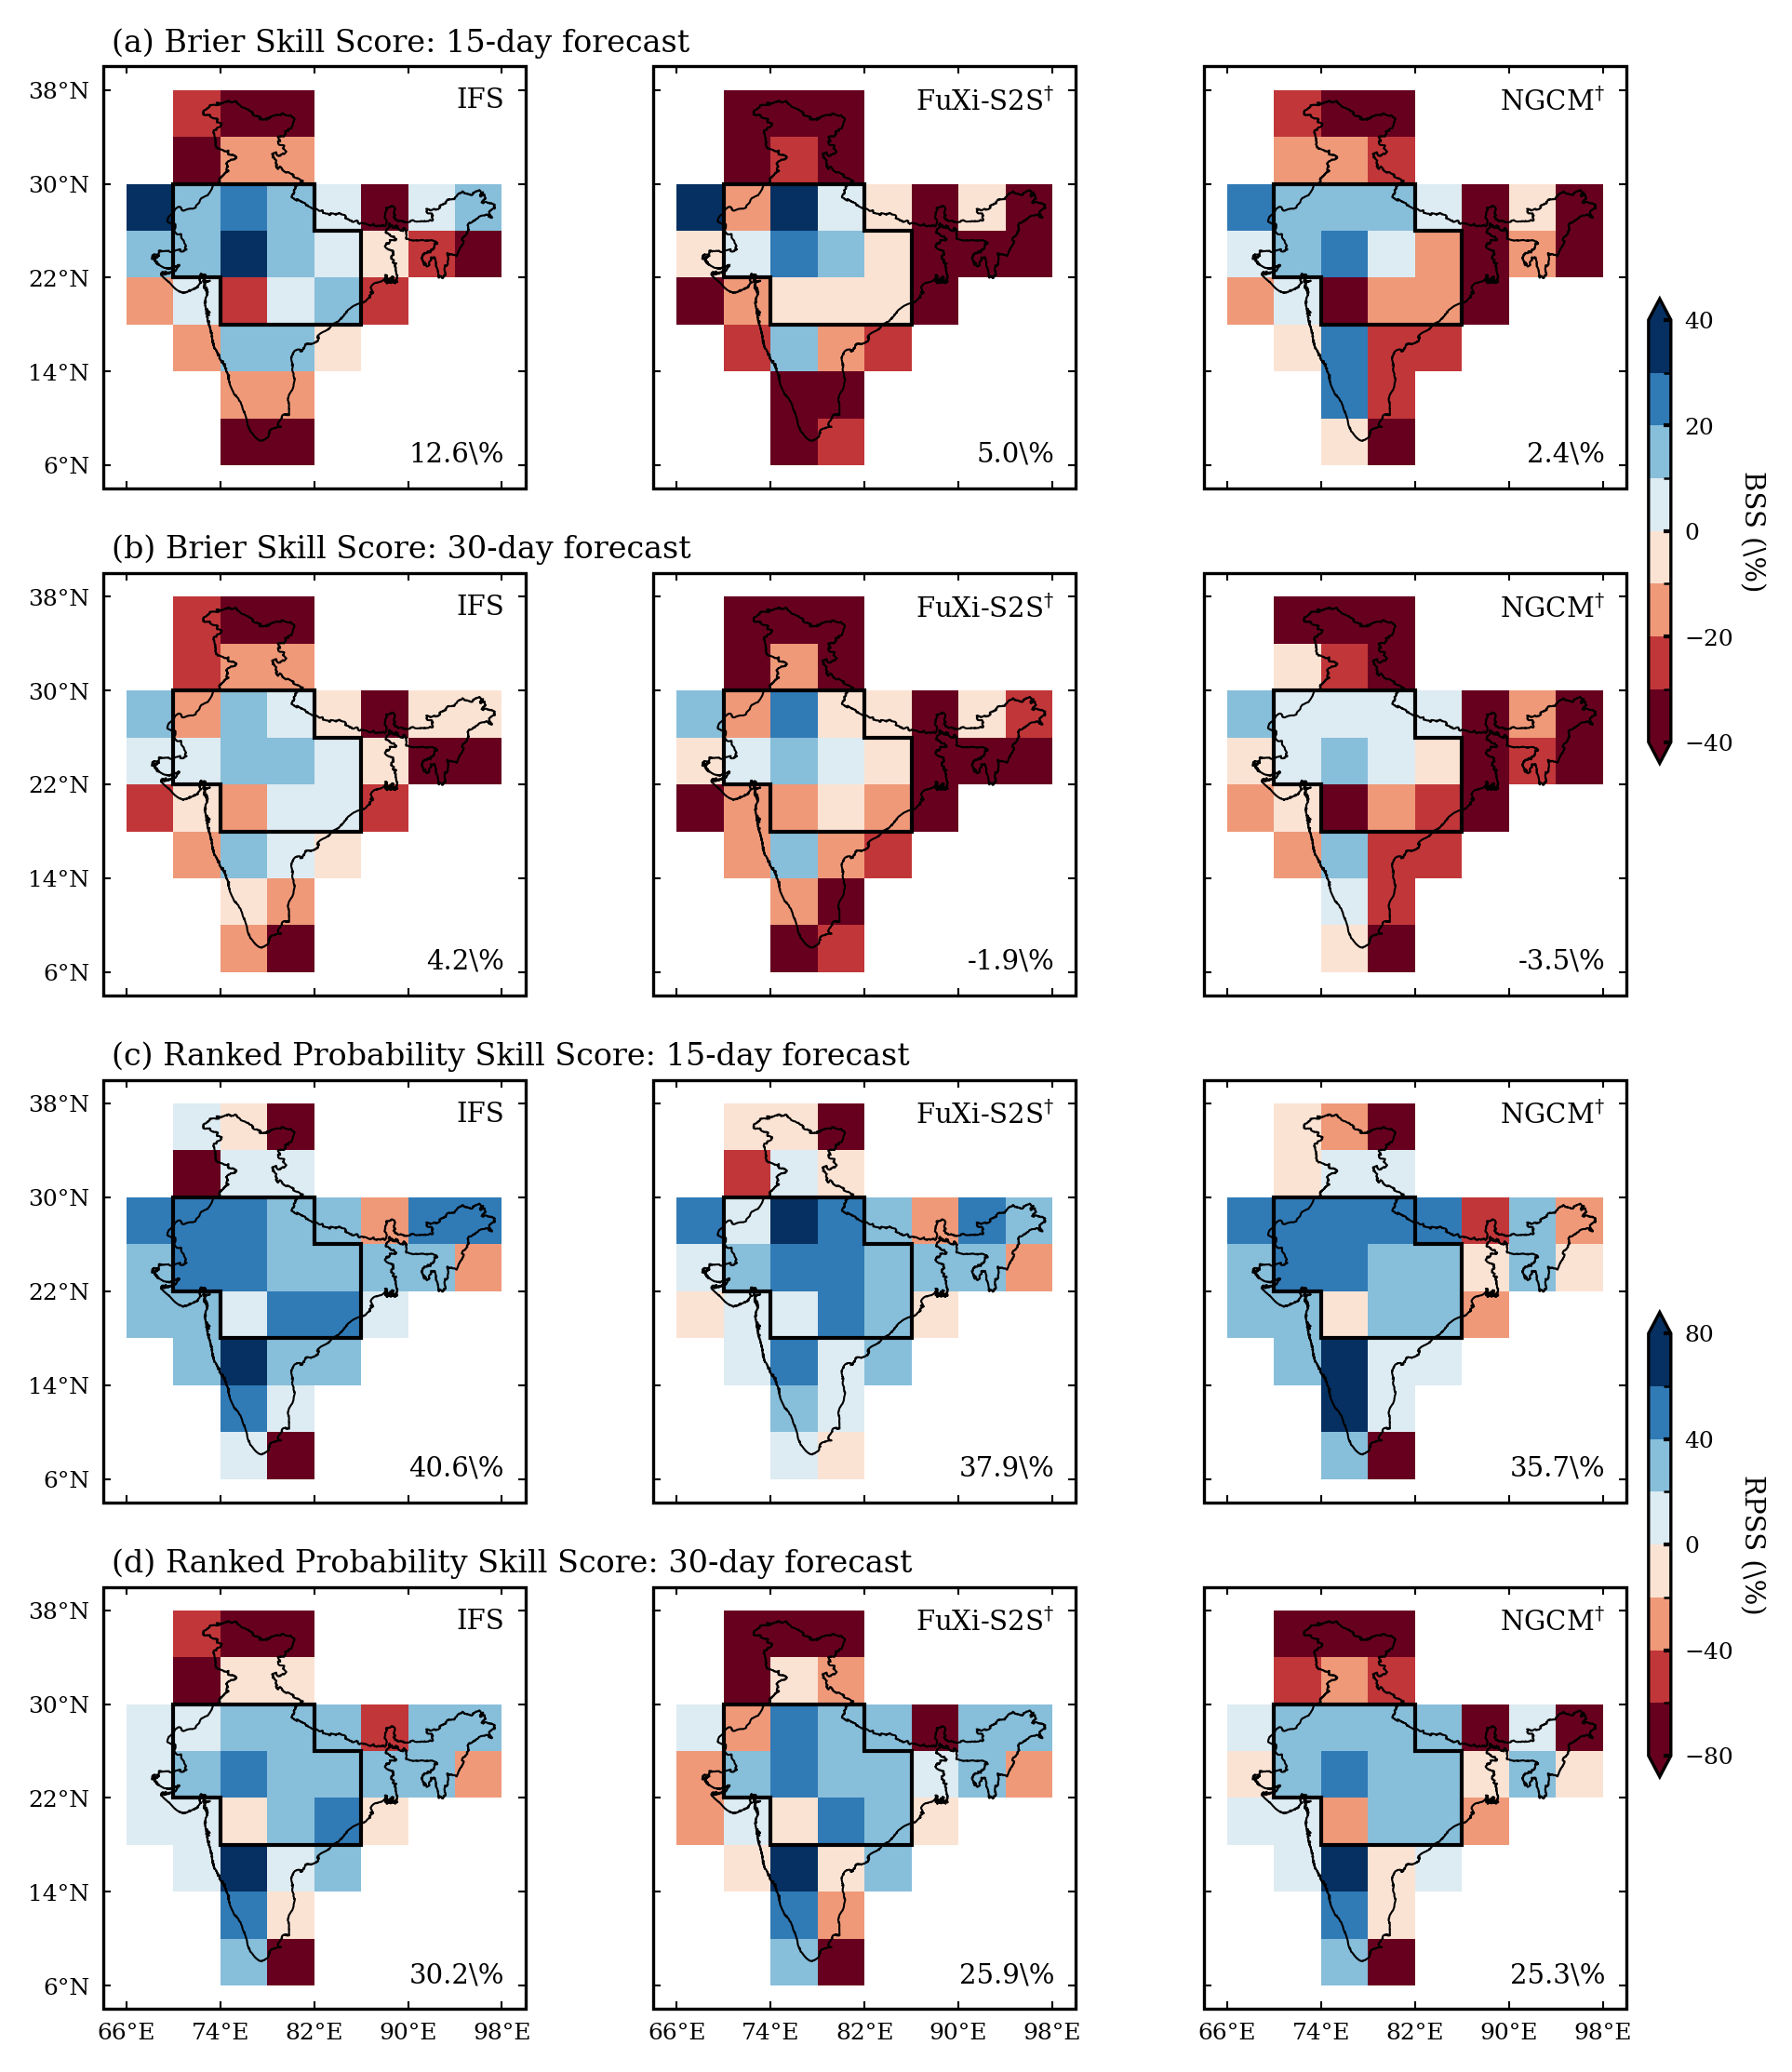

In [7]:
# Create the figure with 4-row layout
skill_fig, gridded_data = create_skill_maps_figure_xr()
plt.show()